# Лабораторна Робота №5
## Тема:  Алгоритми пошуку. Стратегія "грубої сили".
### Мета: Засвоїти варіанти реалізації алгоритмів пошуку засобами Python і методи оцінки їх складності.
#### Виконав: Гнатюк Євгеній

# Порядок виконання роботи
## Завдання 1: Оцінити асимптотичну складність алгоритму лінійного пошуку у О-нотації.


In [15]:
def linear_search(a_list, x):
    i, length = 0, len(a_list)

    while i < length and x != a_list[i]:
        i += 1
    return i if i < length else -1

a = [32, 1, 3, 4, 2, 1]
search_item = 7
print(f"Індекс елемента: {linear_search(a, search_item)}")

Індекс елемента: -1


Часова складність (найгірший випадок): $O(n)$. Якщо шуканого елемента немає в масиві (як у прикладі з цифрою 7) або він стоїть на останньому місці, алгоритму доведеться перевірити кожен з $n$ елементів списку.

Часова складність (найкращий випадок): $O(1)$. Якщо шуканий елемент знаходиться на першій позиції, цикл завершиться після першої ж ітерації.

# Завдання 2: Оцінити асимптотичну складність алгоритму бінарного пошуку пошуку у О-нотації. написати функцію, яка б могла повертати датафрейм з наступним складом полів: ("n", "time"), де n -- розмір масиву для функції `linear_searh(); написати функцію, яка б могла повертати датафрейм з наступним складом полів: ("n", "time"), де n -- розмір масиву для функції `bin_searh(); за результатами попередніх завдань побудувати графіки залежності часу виконання процедури пошуку від розміру масиву. Приклад побудови графіків у середовищі Ipython можна подивитися тут. оцінити, який з двох алгоритмів є більш ефективним та в якому діапазоні розміру задачі

Дані лінійного пошуку:
       n      time
0    10  0.000002
1   100  0.000007
2   500  0.000038
3  1000  0.000080
4  5000  0.000703 

Дані бінарного пошуку:
       n      time
0    10  0.000003
1   100  0.000005
2   500  0.000003
3  1000  0.000003
4  5000  0.000004 



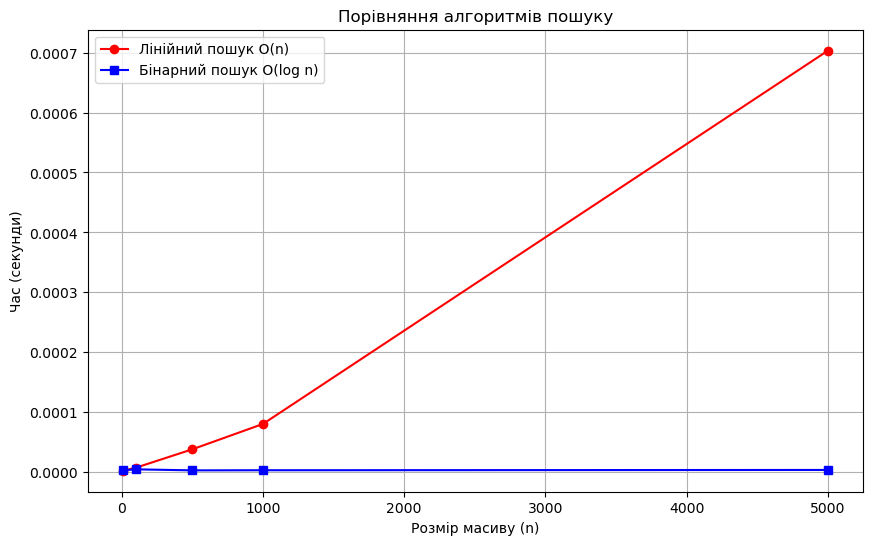

In [16]:
import time
import pandas as pd
import matplotlib.pyplot as plt

def linear_search(a_list, x):
    i, length = 0, len(a_list)
    while i < length and x != a_list[i]:
        i += 1
    return i if i < length else -1

def bin_search(a_list, x, left, right):
    if left > right or len(a_list) == 0:
        return -1
    middle = (left + right) // 2
    if a_list[middle] == x:
        return middle
    elif a_list[middle] < x:
        return bin_search(a_list, x, middle + 1, right)
    else:
        return bin_search(a_list, x, left, middle - 1)

def get_linear_search_df(n_values):
    data = []
    for n in n_values:
        arr = list(range(n))
        
        t0 = time.perf_counter()
        linear_search(arr, -1)  # Шукаємо неіснуючий елемент (найгірший випадок)
        t_total = time.perf_counter() - t0
        
        data.append({"n": n, "time": t_total})
    return pd.DataFrame(data)

def get_bin_search_df(n_values):
    data = []
    for n in n_values:
        arr = list(range(n))
        
        t0 = time.perf_counter()
        bin_search(arr, -1, 0, len(arr) - 1)
        t_total = time.perf_counter() - t0
        
        data.append({"n": n, "time": t_total})
    return pd.DataFrame(data)

n_values = [10, 100, 500, 1000, 5000]

df_linear = get_linear_search_df(n_values)
df_bin = get_bin_search_df(n_values)

print("Дані лінійного пошуку:\n", df_linear.head(), "\n")
print("Дані бінарного пошуку:\n", df_bin.head(), "\n")

plt.figure(figsize=(10, 6))
plt.plot(df_linear["n"], df_linear["time"], 'r-o', label='Лінійний пошук O(n)')
plt.plot(df_bin["n"], df_bin["time"], 'b-s', label='Бінарний пошук O(log n)')

plt.title('Порівняння алгоритмів пошуку')
plt.xlabel('Розмір масиву (n)')
plt.ylabel('Час (секунди)')
plt.legend()
plt.grid(True)
plt.show()


# Контрольні запитання:
1. $\Omega$ (Омега): Нижня межа складності (мінімальний час роботи алгоритму, найкращий випадок).
2. $O(N^3)$.
3. $O(1.01^N)$ (експоненціальна функція росте швидше за поліном).
4. $O(N^{1.3})$ (ступенева функція росте швидше за логарифмічну).
5. Розпаралелювання: Одночасне виконання різних частин задачі на кількох ядрах. З базових алгоритмів розпаралелюється сортування злиттям (Merge Sort).
6. Шляхи: Апаратний (кращий ПК), розпаралелювання, алгоритмічний. Найефективніший — алгоритмічний (заміна самого алгоритму на більш оптимальний).